In [35]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple


def analyze_halos(
    filepath: str,
    num_halos: int,
    b_min: float,
    b_max: float,
    M_200_min: float,
    M_200_max: float,
    sfr_min: float,
    sfr_max: float,
    random_seed: int = 42
) -> Tuple[dict, pd.DataFrame]:
    """
    Analyze halos from a CSV file with filtering and weighting.
    
    Parameters:
    -----------
    filepath : str
        Absolute path to the CSV file
    num_halos : int
        Number of halos to randomly sample
    b_min, b_max : float
        Min and max impact parameter values to filter
    M_200_min, M_200_max : float
        Min and max M_200 values to filter
    sfr_min, sfr_max : float
        Min and max SFR values to filter
    random_seed : int, optional
        Random seed for reproducibility
        
    Returns:
    --------
    results : dict
        Dictionary containing analysis results
    sampled_data : pd.DataFrame
        The sampled data that was used for analysis
    """
    # Set random seed for reproducibility
    np.random.seed(random_seed)
    
    # Load the CSV file
    df = pd.read_csv(filepath,names=['x_pos', 'y_pos', 'dm_total', 'b_val', 'halo_index', 'M_star', 'M_200', 'sfr'])
    
    # Filter the data based on given criteria
    filtered_df = df[
        (df['b_val'] >= b_min) & 
        (df['b_val'] <= b_max) & 
        (df['M_200'] >= M_200_min) & 
        (df['M_200'] <= M_200_max) & 
        (df['sfr'] >= sfr_min) & 
        (df['sfr'] <= sfr_max)
    ]
    
    # Check if we have enough data after filtering
    if len(filtered_df) < num_halos:
        raise ValueError(
            f"Not enough halos after filtering. Found {len(filtered_df)}, "
            f"but requested {num_halos}."
        )
    
    # 1. Randomly sample the desired number of halos
    sampled_indices = np.random.choice(
        filtered_df.index, 
        size=num_halos, 
        replace=False
    )
    sampled_data = filtered_df.loc[sampled_indices].copy()
    
    # 2. Compute unweighted mean and standard deviation of dm_total
    unweighted_mean = sampled_data['dm_total'].mean()
    unweighted_std = sampled_data['dm_total'].std()
    
    # 3. Compute weights proportional to M_star
    # Normalize the weights so they sum to 1
    if weighting == 'M_star':
        weights = sampled_data['M_star'] / sampled_data['M_star'].sum()
    if weighting == 'sfr':
        weights = sampled_data['sfr'] / sampled_data['sfr'].sum()
    if weighting == 'both':
        weights = sampled_data['sfr'] * sampled_data['M_star'] / (sampled_data['sfr'] * sampled_data['M_star']).sum()

    sampled_data['weight'] = weights
    
    # 4. Apply weights to the DM distribution
    # For weighted mean: sum(weight * value) / sum(weights)
    # For weighted variance: sum(weight * (value - weighted_mean)^2) / sum(weights)
    weighted_mean = np.sum(weights * sampled_data['dm_total'])
    weighted_var = np.sum(weights * (sampled_data['dm_total'] - weighted_mean)**2)
    weighted_std = np.sqrt(weighted_var)
    
    # 5. Compile results
    results = {
        'unweighted_mean': unweighted_mean,
        'unweighted_std': unweighted_std,
        'weighted_mean': weighted_mean,
        'weighted_std': weighted_std,
        'num_sampled_halos': num_halos,
        'num_filtered_halos': len(filtered_df),
        'sample_fraction': num_halos / len(filtered_df),
        'filter_criteria': {
            'b_range': (b_min, b_max),
            'M_200_range': (M_200_min, M_200_max),
            'sfr_range': (sfr_min, sfr_max)
        }
    }
    
    return df,results, sampled_data


def visualize_results(results: dict, sampled_data: pd.DataFrame) -> None:
    """
    Visualize the results of the halo analysis.
    
    Parameters:
    -----------
    results : dict
        Dictionary containing analysis results
    sampled_data : pd.DataFrame
        The sampled data that was used for analysis
    """
    # Set up a figure with subplots
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Histogram of dm_total with both weighted and unweighted statistics
    title = f"N = {results['num_filtered_halos']} halos sampled uniformly in sightline"
    fig.suptitle(title)
    ax = axs[0, 0]
    ax.hist(sampled_data['dm_total'], bins=20, alpha=0.7, color='skyblue')
    ax.axvline(results['unweighted_mean'], color='blue', linestyle='-', 
               label=f"Unweighted Mean: {results['unweighted_mean']:.2f}")
    ax.axvline(results['weighted_mean'], color='red', linestyle='-', 
               label=f"Weighted Mean: {results['weighted_mean']:.2f}")
    
    # Add shaded regions for standard deviations
    ax.axvspan(
        results['unweighted_mean'] - results['unweighted_std'],
        results['unweighted_mean'] + results['unweighted_std'],
        alpha=0.2, color='blue'
    )
    ax.axvspan(
        results['weighted_mean'] - results['weighted_std'],
        results['weighted_mean'] + results['weighted_std'],
        alpha=0.2, color='red'
    )
    ax.set_xlabel('DM Total')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of DM Total')
    ax.legend()
    
    # Plot 2: Scatter plot of M_star vs dm_total
    ax = axs[0, 1]
    ax.set_xscale('log')
    sc = ax.scatter(sampled_data['M_star'], sampled_data['dm_total'], 
                   c=sampled_data['weight'], cmap='viridis', alpha=0.7)
    ax.set_xlabel('M_star')
    ax.set_ylabel('DM Total')
    ax.set_title('M_star vs DM Total (color = weight)')
    plt.colorbar(sc, ax=ax, label='Weight')
    
    # Plot 3: Scatter plot of M_200 vs dm_total
    ax = axs[1, 0]
    ax.set_xscale('log')
    ax.scatter(sampled_data['M_200'], sampled_data['dm_total'], alpha=0.7)
    ax.set_xlabel('M_200')
    ax.set_ylabel('DM Total')
    ax.set_title('M_200 vs DM Total')
    
    # Plot 4: Scatter plot of impact parameter vs dm_total
    ax = axs[1, 1]
    ax.scatter(sampled_data['b_val'], sampled_data['dm_total'], alpha=0.7)
    ax.set_xlabel('Impact Parameter (b_val)')
    ax.set_ylabel('DM Total')
    ax.set_title('Impact Parameter vs DM Total')

    
    plt.tight_layout()
    plt.show()




Analysis Results:
----------------------------------------
Number of sampled halos: 100
Total halos after filtering: 2428
Sample fraction: 4.12%

DM Total Statistics:
Unweighted Mean: 251.8535
Unweighted Std Dev: 159.7039
Weighted Mean (by M_star): 335.0931
Weighted Std Dev (by M_star): 179.6427

Filtering Criteria:
Impact Parameter Range: (0.0, 100.0)
M_200 Range: (100000000000.0, 100000000000000.0)
SFR Range: (0.1, 100.0)


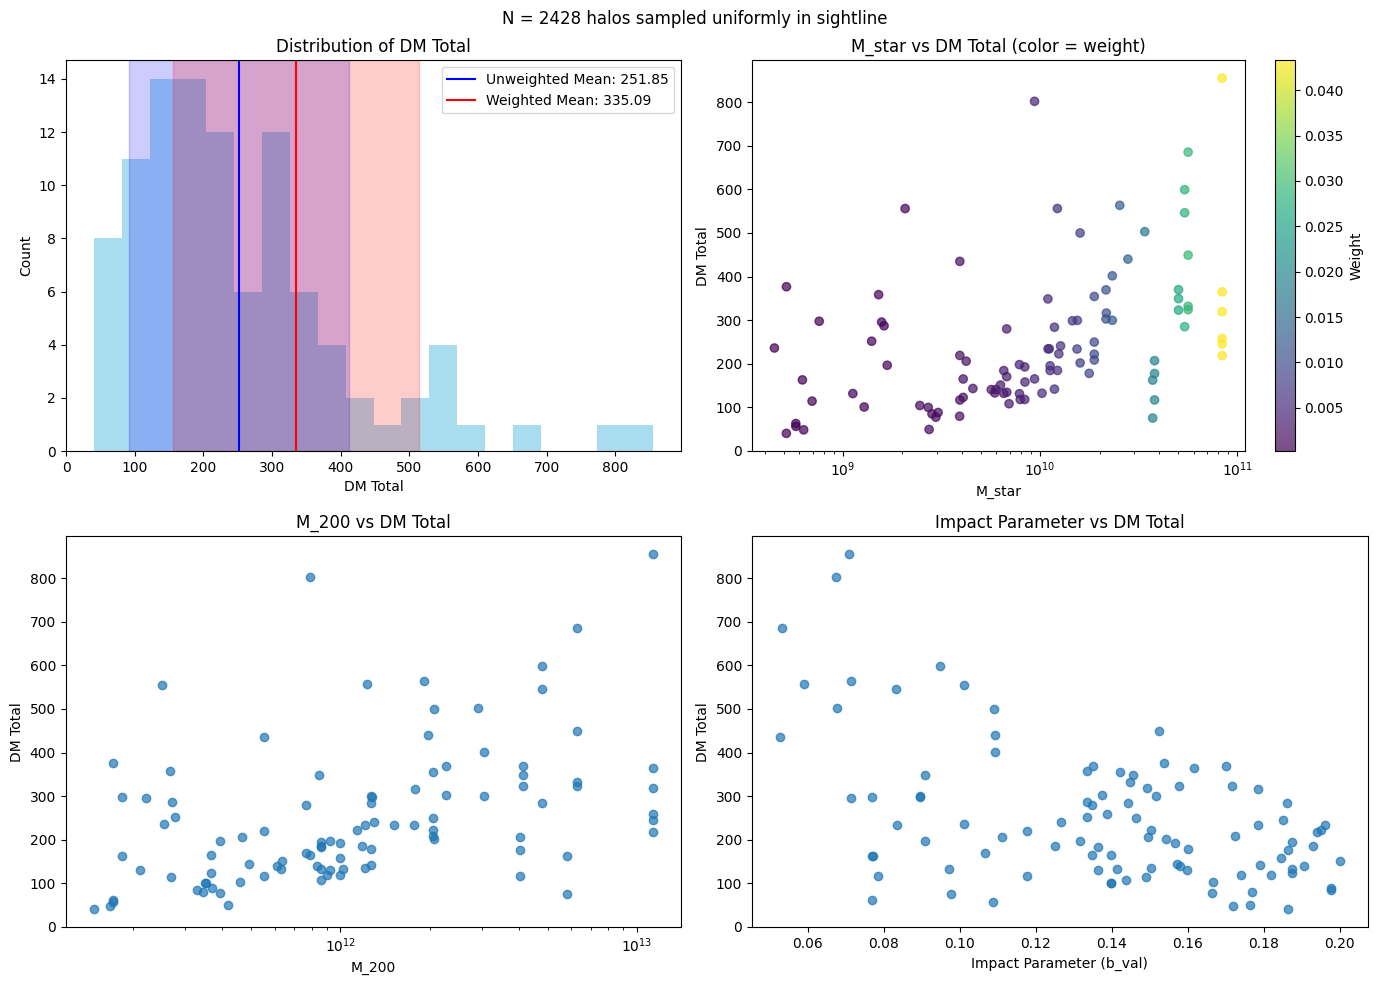

In [36]:
root_path = os.getcwd() + '/../'

filepath = os.path.join(root_path,'data_products','camels_data','20250414','Astrid_1P_3_0_snap090_haloDM.csv')

# Parameters
num_halos = 100
b_min = 0.0
b_max = 100.0
M_200_min = 1e11
M_200_max = 1e14
sfr_min = 0.1
sfr_max = 100.0

# Run the analysis
df, results, sampled_data = analyze_halos(
    filepath=filepath,
    num_halos=num_halos,
    b_min=b_min,
    b_max=b_max,
    M_200_min=M_200_min,
    M_200_max=M_200_max,
    sfr_min=sfr_min,
    sfr_max=sfr_max
)

# Print results
print("\nAnalysis Results:")
print("-" * 40)
print(f"Number of sampled halos: {results['num_sampled_halos']}")
print(f"Total halos after filtering: {results['num_filtered_halos']}")
print(f"Sample fraction: {results['sample_fraction']:.2%}")
print("\nDM Total Statistics:")
print(f"Unweighted Mean: {results['unweighted_mean']:.4f}")
print(f"Unweighted Std Dev: {results['unweighted_std']:.4f}")
print(f"Weighted Mean (by M_star): {results['weighted_mean']:.4f}")
print(f"Weighted Std Dev (by M_star): {results['weighted_std']:.4f}")
print("\nFiltering Criteria:")
print(f"Impact Parameter Range: {results['filter_criteria']['b_range']}")
print(f"M_200 Range: {results['filter_criteria']['M_200_range']}")
print(f"SFR Range: {results['filter_criteria']['sfr_range']}")

# Visualize the results
visualize_results(results, sampled_data)

In [22]:
df

,x_pos,y_pos,dm_total,b_val,halo_index,M_star,M_200,sfr
0,1272.0,1804.0,177.796770,0.131762,41.0,1.095598e+10,1.212033e+12,0.546174
1,3177.0,3605.0,172.390587,0.142857,222.0,1.472321e+09,2.478332e+11,0.328180
2,3105.0,1259.0,122.395325,0.190476,78.0,5.756817e+09,7.567747e+11,0.053342
3,2883.0,136.0,87.053903,0.071429,232.0,1.601405e+09,2.378553e+11,0.109312
4,3097.0,1078.0,162.219550,0.137490,52.0,8.784550e+09,9.930927e+11,0.314970
...,...,...,...,...,...,...,...,...
4276,2138.0,2746.0,102.712980,0.058824,103.0,3.443495e+09,3.972623e+11,0.018320
4277,2577.0,841.0,506.812407,0.108786,26.0,1.537867e+10,1.513455e+12,1.694393
4278,3078.0,2312.0,269.076427,0.071429,267.0,1.123539e+09,2.090376e+11,0.168928
4279,544.0,2456.0,46.792202,0.197642,160.0,1.700266e+09,3.477797e+11,0.019862


In [26]:
25 / 0.7

35.714285714285715

In [25]:
df['x_pos']

0       1272.0
1       3177.0
2       3105.0
3       2883.0
4       3097.0
         ...  
4276    2138.0
4277    2577.0
4278    3078.0
4279     544.0
4280    2738.0
Name: x_pos, Length: 4281, dtype: float64

In [27]:
df

,x_pos,y_pos,dm_total,b_val,halo_index,M_star,M_200,sfr
0,1272.0,1804.0,177.796770,0.131762,41.0,1.095598e+10,1.212033e+12,0.546174
1,3177.0,3605.0,172.390587,0.142857,222.0,1.472321e+09,2.478332e+11,0.328180
2,3105.0,1259.0,122.395325,0.190476,78.0,5.756817e+09,7.567747e+11,0.053342
3,2883.0,136.0,87.053903,0.071429,232.0,1.601405e+09,2.378553e+11,0.109312
4,3097.0,1078.0,162.219550,0.137490,52.0,8.784550e+09,9.930927e+11,0.314970
...,...,...,...,...,...,...,...,...
4276,2138.0,2746.0,102.712980,0.058824,103.0,3.443495e+09,3.972623e+11,0.018320
4277,2577.0,841.0,506.812407,0.108786,26.0,1.537867e+10,1.513455e+12,1.694393
4278,3078.0,2312.0,269.076427,0.071429,267.0,1.123539e+09,2.090376e+11,0.168928
4279,544.0,2456.0,46.792202,0.197642,160.0,1.700266e+09,3.477797e+11,0.019862


(array([1838., 1137.,  602.,  328.,  137.,  100.,   57.,   33.,   28.,
          21.]),
 array([  7.79661356, 105.83366075, 203.87070794, 301.90775513,
        399.94480232, 497.98184951, 596.0188967 , 694.05594389,
        792.09299108, 890.13003827, 988.16708546]),
 <BarContainer object of 10 artists>)

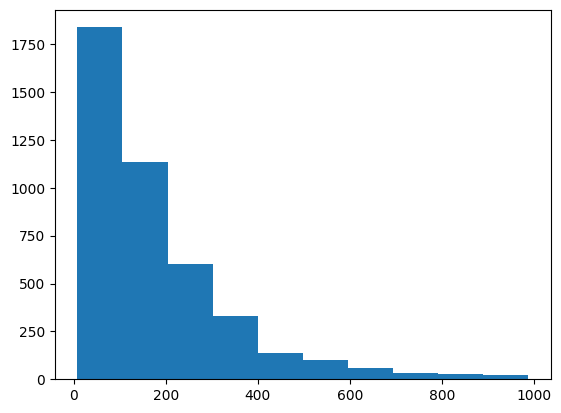

In [28]:
plt.figure()
plt.hist(df['dm_total'])

In [14]:
results

{'unweighted_mean': np.float64(251.85349445574695),
 'unweighted_std': 159.70387128566804,
 'weighted_mean': np.float64(335.0930894391726),
 'weighted_std': np.float64(179.6426657507672),
 'num_sampled_halos': 100,
 'num_filtered_halos': 2428,
 'sample_fraction': 0.04118616144975288,
 'filter_criteria': {'b_range': (0.0, 100.0),
  'M_200_range': (100000000000.0, 100000000000000.0),
  'sfr_range': (0.1, 100.0)}}